<a href="https://www.kaggle.com/code/eavprog/absolute-fx-correlation-matrix-mapping-real-curre?scriptVersionId=304834332" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Корреляционный анализ «чистых» валютных курсов (Log-Returns)

# Введение и концептуальный фундамент
Это исследование посвящено анализу динамических взаимосвязей между мировыми валютами. В отличие от классического анализа валютных пар, где доминирует влияние доллара США, мы используем **абсолютные курсы** (Absolute Currency Rates). Это позволяет увидеть реальную степень синхронности или независимости национальных экономик.

### Полезные ресурсы:
* [Связанность валют через корреляцию абсолютных курсов](https://www.abscur.ru/p/blog-page_22.html) — Интерактивная визуализация (графы) сильнейших связей между курсами. Позволяет увидеть «валютные блоки» и доминирующие активы.
* [Связанность валют через корреляцию доходности курсов](https://www.abscur.ru/p/blog-page_72.html) — Сравнение корреляций на разных временных интервалах (от месяца до 10 лет) в виде графовых моделей.

# 1. Загрузка и первичная подготовка данных

Для обеспечения статистической достоверности корреляционного анализа мы используем фиксированный горизонт в **10 лет**. Это позволяет выявить устойчивые долгосрочные взаимосвязи между экономиками, нивелируя краткосрочный рыночный шум и случайные колебания.

**Основные этапы подготовки:**
* **Ограничение горизонта**: Выборка данных строго за последние 10 лет от текущей даты.
* **Фильтрация активов**: В расчет включаются только те валюты, которые имеют полную или почти полную историю котировок (не менее 90% заполненности) за выбранный период. Это исключает искажение матрицы корреляций «молодыми» или нестабильными активами.
* **Очистка (Data Cleaning)**: Заполнение локальных пропусков методами `ffill` (вперед) и `bfill` (назад) для обеспечения непрерывности временных рядов.

В результате мы получаем очищенную матрицу абсолютных курсов, готовую к расчету логарифмических доходностей.



In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Загрузка данных
# Используем тот же путь к датасету abscur
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'
df_raw = pd.read_csv(file_path, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').set_index('Date')

# 2. Ограничение горизонта (10 лет)
# Берем данные от текущей даты минус 10 лет
end_date = df_raw.index.max()
start_date = end_date - pd.DateOffset(years=10)

df = df_raw.loc[start_date:end_date].copy()

# 3. Очистка и подготовка (Data Cleaning)
# Удаляем валюты, которые появились недавно и не имеют истории за 10 лет
# (чтобы не искажать матрицу корреляций короткими отрезками)
min_required_days = 250 * 9 # Примерно 9 лет торговых дней
df = df.dropna(axis=1, thresh=min_required_days)

# Заполняем локальные пропуски (праздники, сбои котировок)
df = df.ffill().bfill()

# 4. Проверка результата
if df.isnull().values.any():
    print("⚠️ Внимание: в данных остались пропуски!")
else:
    print(f"✅ Данные успешно загружены за период: {start_date.date()} — {end_date.date()}")
    print(f"✅ В анализе участвует {df.shape[1]} валют с полной историей.")

# Выведем первые 5 строк для контроля
display(df.head())

✅ Данные успешно загружены за период: 2016-03-18 — 2026-03-18
✅ В анализе участвует 45 валют с полной историей.


,AED,ARS,AUD,BRL,CAD,CHF,CLP,CNY,COP,CZK,...,SAR,SEK,SGD,THB,TRY,TWD,UAH,USD,VND,ZAR
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-18,4.405148,1.085766,12.002558,4.464102,13.031597,18.492781,0.023942,2.505425,0.005266,0.676843,...,4.314454,1.774442,12.874364,0.464882,5.644375,0.501097,0.610487,16.177906,0.000726,1.061945
2016-03-20,4.405233,1.085786,12.002062,4.464188,13.031061,18.492011,0.023942,2.505410,0.005266,0.676839,...,4.314537,1.774373,12.873828,0.464891,5.644483,0.501106,0.610499,16.178218,0.000726,1.061938
2016-03-21,4.408720,1.096924,11.976078,4.476856,12.980256,18.461015,0.023940,2.502700,0.005271,0.674671,...,4.318422,1.772086,12.848755,0.463711,5.659044,0.501061,0.616868,16.192788,0.000727,1.065710
2016-03-22,4.405337,1.125046,11.965224,4.518282,12.971580,18.416240,0.024057,2.497965,0.005343,0.672519,...,4.314521,1.768807,12.824729,0.463027,5.641511,0.499449,0.619853,16.178161,0.000726,1.067059
2016-03-23,4.425934,1.130460,11.944533,4.413917,12.925646,18.420143,0.023860,2.503864,0.005288,0.673479,...,4.334937,1.767541,12.821385,0.461819,5.652889,0.501265,0.624031,16.256013,0.000727,1.061609


# 2. Математический аппарат: Логарифмические доходности

На этом этапе мы переходим от сырых ценовых данных к их динамическим характеристикам. Использование логарифмических доходностей (Log-Returns) вместо обычных процентных изменений является стандартом в количественных финансах при работе с временными рядами.

**Основные преимущества метода:**
* **Аддитивность во времени**: Сумма логарифмических доходностей за несколько периодов равна логарифмической доходности за весь период, что упрощает масштабирование анализа.
* **Стационарность**: В отличие от курсов валют, которые имеют выраженные тренды, доходности колеблются вокруг нуля. Это критически важное условие для корректного расчета коэффициента корреляции Пирсона.
* **Симметрия и нормализация**: Лог-доходности лучше справляются с экстремальными рыночными движениями, обеспечивая более надежную статистическую базу для сравнения валют с разным уровнем волатильности.

**Формула расчета:**
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**Визуальный контроль:**
* **Сравнение (Time Series)**: Графики наглядно демонстрируют трансформацию трендового абсолютного курса в стационарный «белый шум» доходностей.
* **Распределение (KDE Plot)**: Позволяет выявить валюты с аномальным поведением (экстремальные хвосты) и подтвердить сопоставимость данных основного массива валют.

В результате мы получаем очищенную матрицу доходностей, готовую к поиску скрытых динамических взаимосвязей.

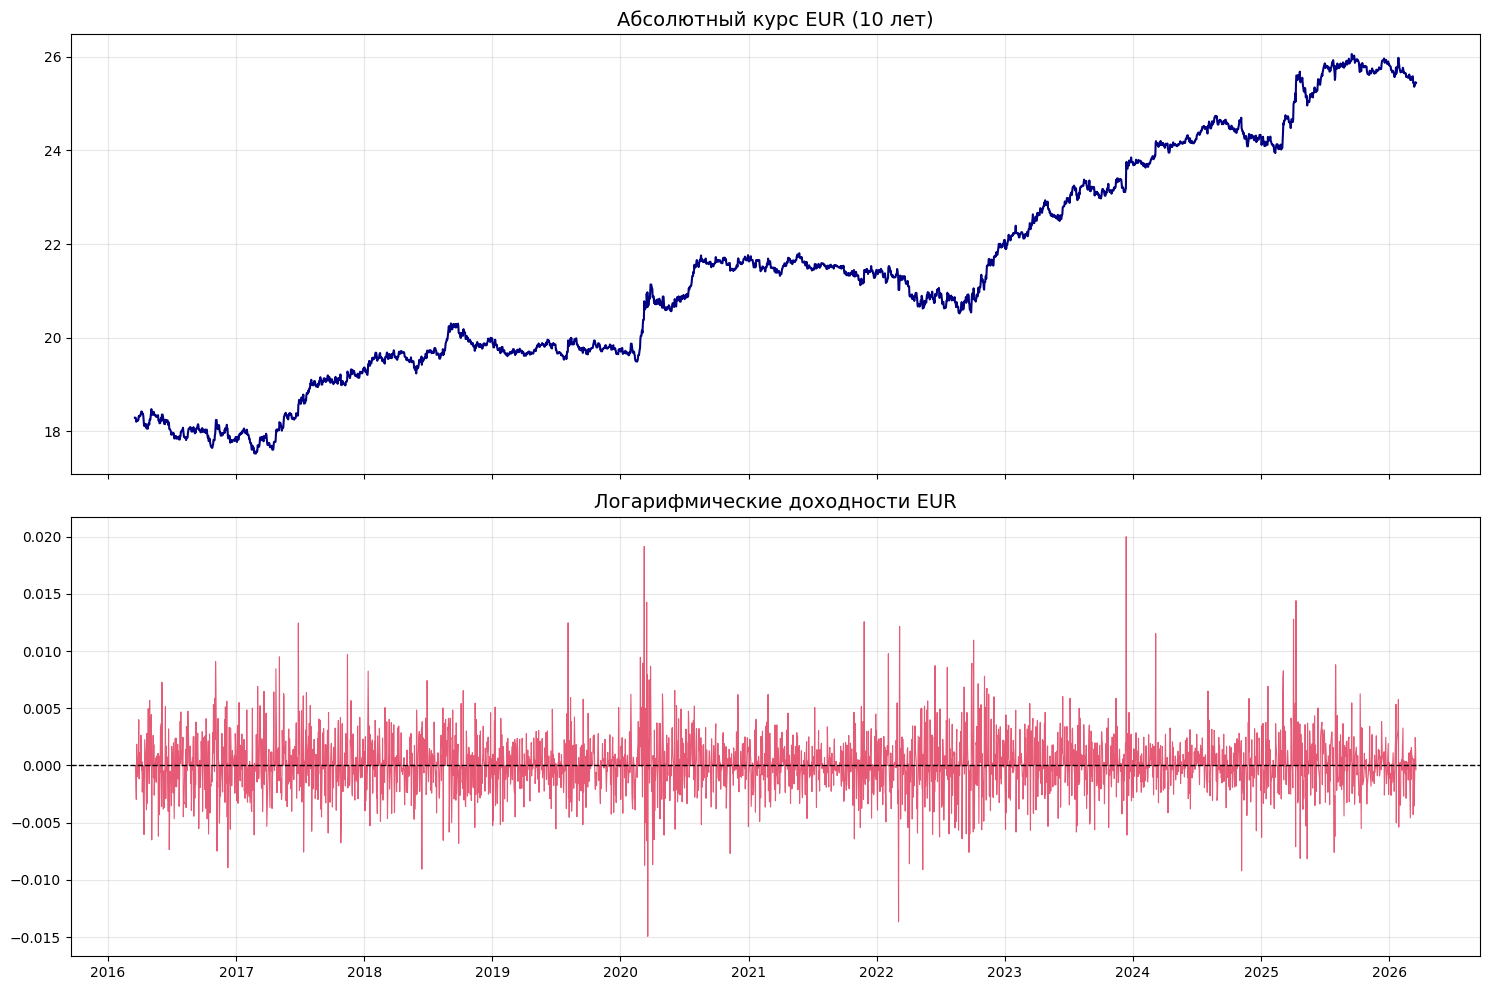

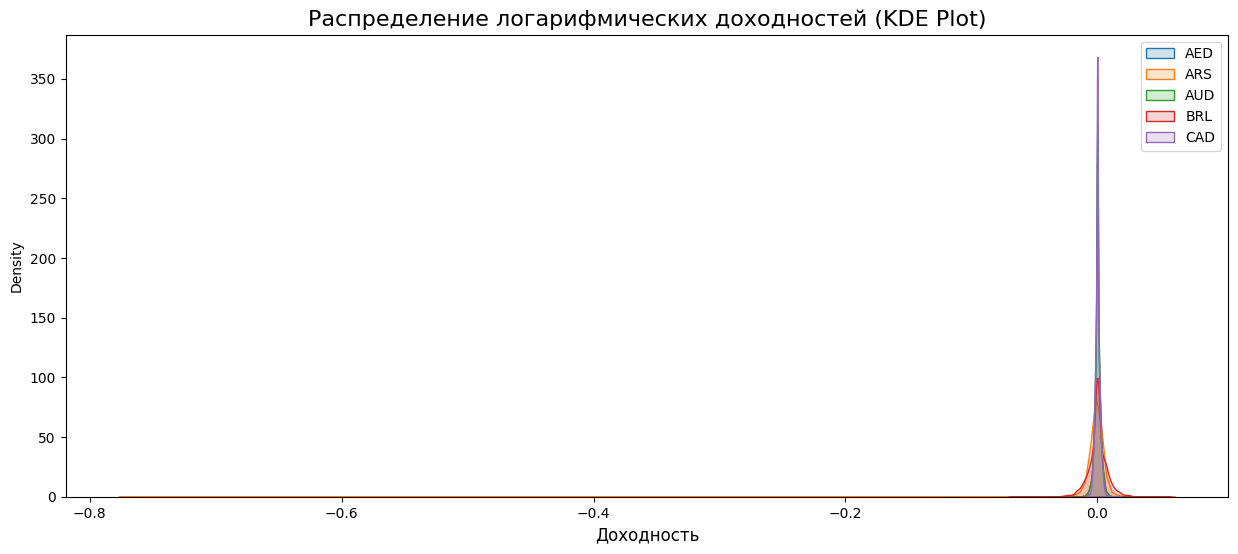

✅ Матрица лог-доходностей готова: 3286 строк x 45 столбцов


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Расчет логарифмических доходностей
# np.log(df / df.shift(1)) — это и есть наша формула ln(Pt / Pt-1)
log_returns = np.log(df / df.shift(1)).dropna()

# 2. Визуальная проверка данных (на примере одной валюты)
example_ticker = 'EUR' # Можно заменить на любой другой из df.columns
if example_ticker in log_returns.columns:
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # График абсолютного курса
    axes[0].plot(df[example_ticker], color='navy', lw=1.5)
    axes[0].set_title(f'Абсолютный курс {example_ticker} (10 лет)', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # График лог-доходностей
    axes[1].plot(log_returns[example_ticker], color='crimson', lw=0.8, alpha=0.7)
    axes[1].set_title(f'Логарифмические доходности {example_ticker}', fontsize=14)
    axes[1].axhline(0, color='black', lw=1, ls='--')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 3. Общая гистограмма распределения (первые 5 валют для примера)
plt.figure(figsize=(15, 6))
for col in log_returns.columns[:5]:
    sns.kdeplot(log_returns[col], label=col, fill=True, alpha=0.2)

plt.title('Распределение логарифмических доходностей (KDE Plot)', fontsize=16)
plt.xlabel('Доходность', fontsize=12)
plt.legend()
plt.show()

print(f"✅ Матрица лог-доходностей готова: {log_returns.shape[0]} строк x {log_returns.shape[1]} столбцов")

# 3. Визуализация: Тепловая карта корреляций (Heatmap)

Этот раздел является центральным элементом исследования. Здесь мы трансформируем массив логарифмических доходностей в наглядную матрицу связей, которая обнажает внутреннюю структуру мирового валютного рынка.

**Методология визуализации:**
* **Иерархическая кластеризация**: Использование метода `ward` позволяет автоматически сгруппировать валюты по силе их взаимосвязи. Это формирует визуальные «блоки» или «зоны влияния», где активы демонстрируют схожую динамику.
* **Треугольная маска**: Отсечение дублирующей верхней части матрицы позволяет сфокусироваться на уникальных парах и делает график читаемым при анализе большого количества активов (45 валют).
* **Цветовое кодирование (Coolwarm)**: 
    * **Красный (ближе к +1.0)**: Высокая положительная корреляция. Валюты двигаются синхронно.
    * **Синий (ближе к -1.0)**: Отрицательная корреляция. Валюты-антиподы, двигающиеся в противофазе.
    * **Белый/Светлый (около 0)**: Независимые активы — идеальные кандидаты для диверсификации.

**Информационная ценность:**
Анализ матрицы позволяет быстро идентифицировать валюты-дублеры и найти скрытые взаимосвязи, которые невозможно заметить при стандартном анализе парных курсов к доллару.

### Полезные ресурсы для сравнения:
* [Связанность валют через корреляцию абсолютных курсов](https://www.abscur.ru/p/blog-page_22.html) — Интерактивная визуализация графов корреляций на сайте проекта.

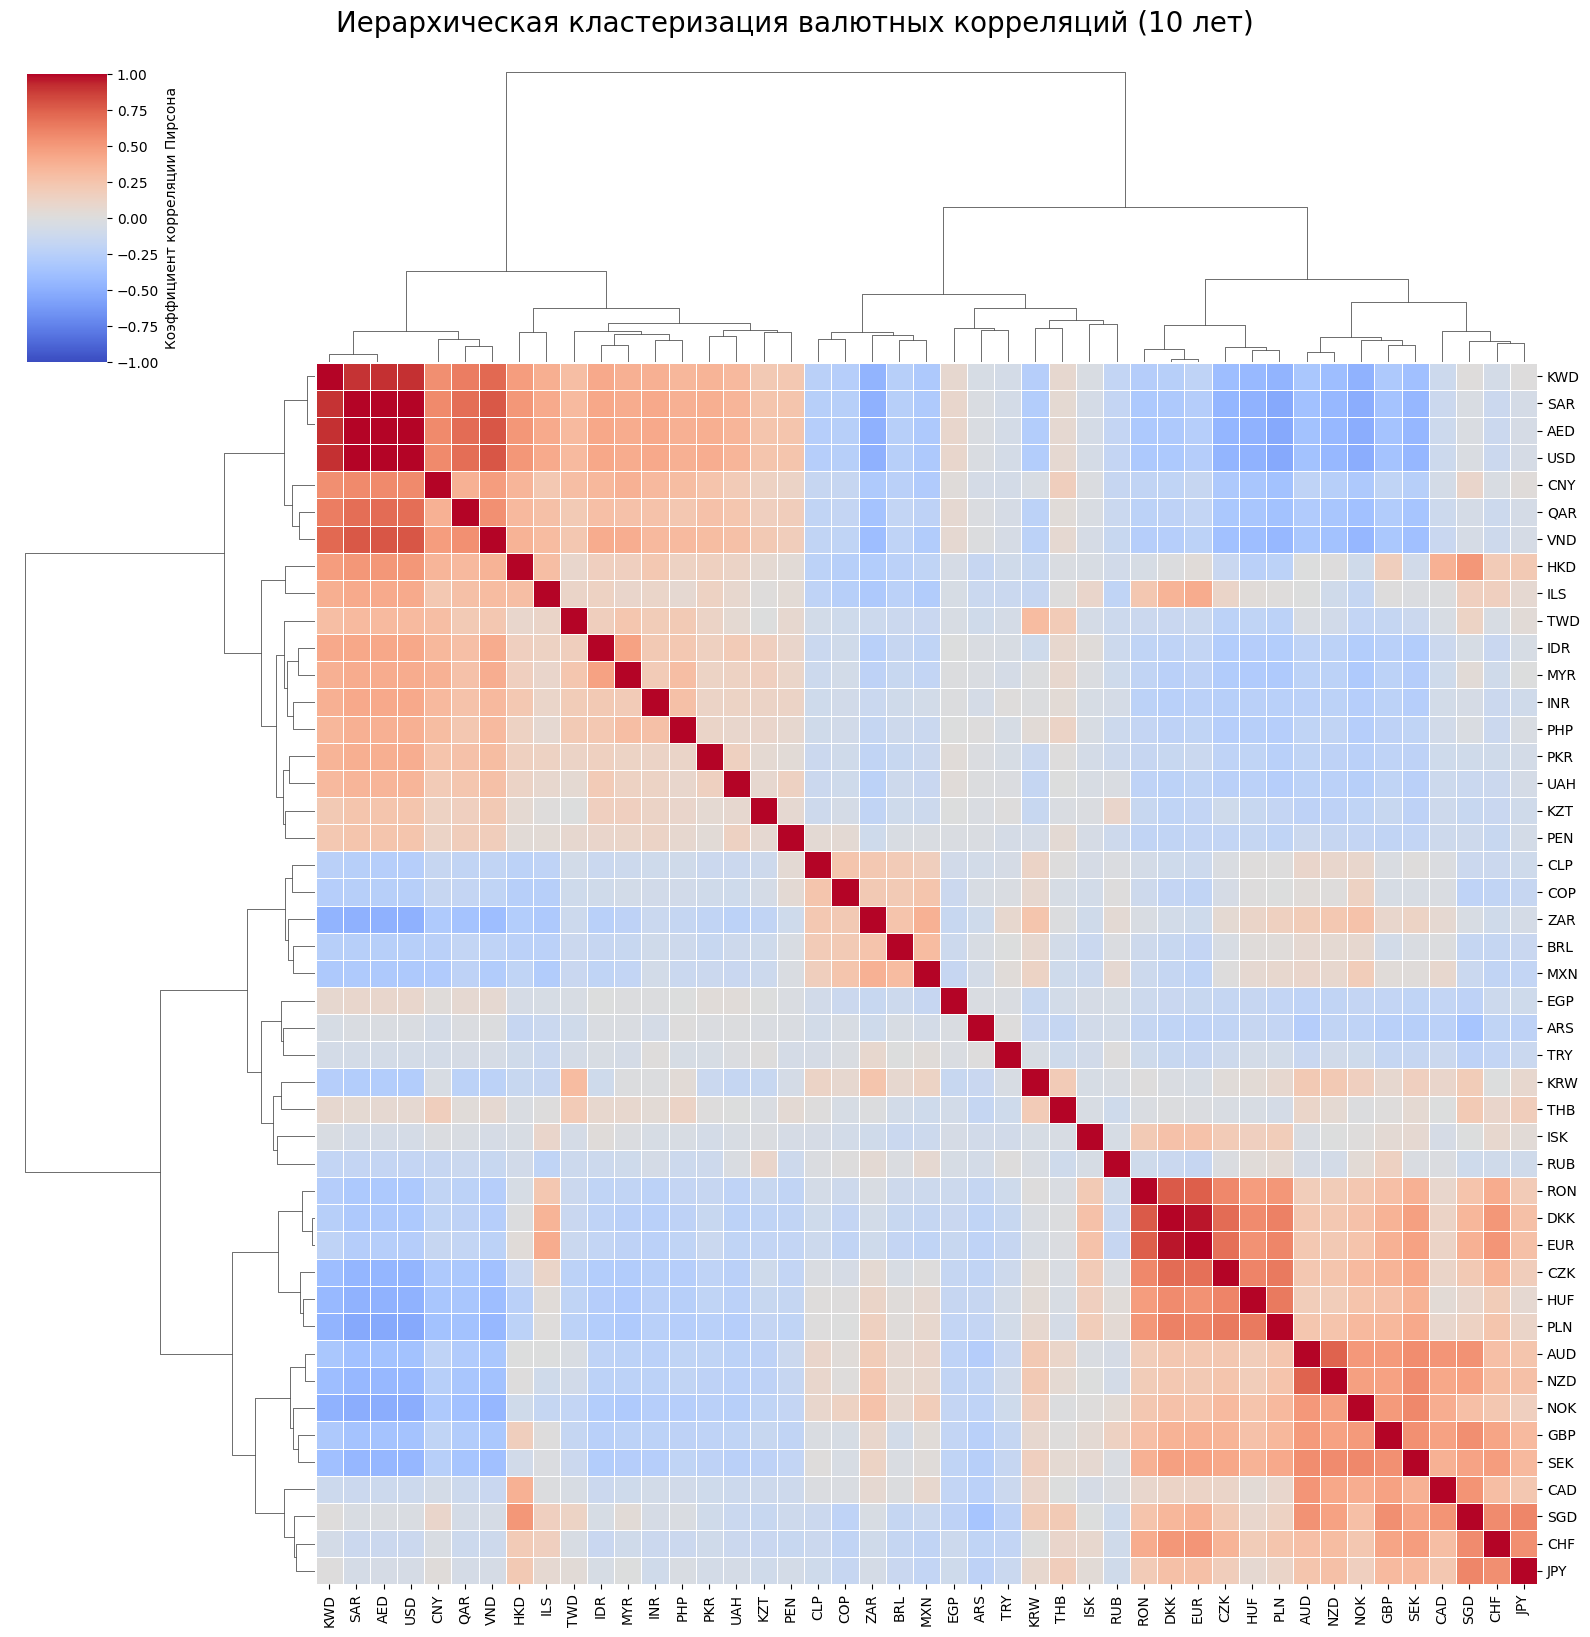

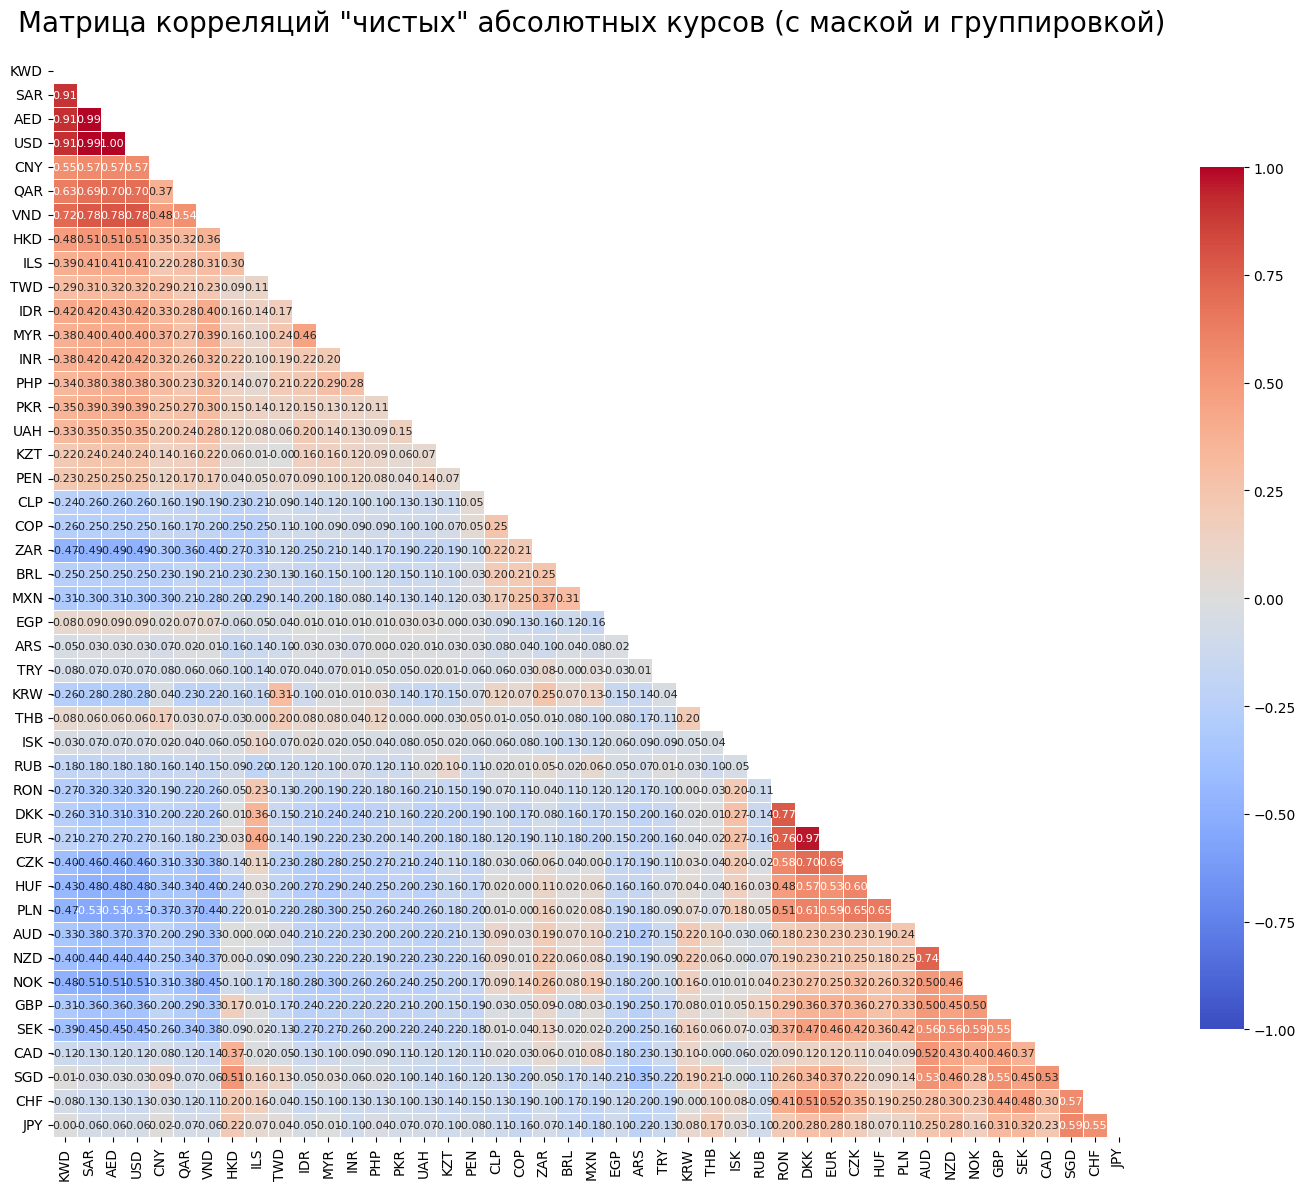

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Расчет матрицы корреляции Пирсона для лог-доходностей
corr_matrix = log_returns.corr()

# 2. Построение кластеризованной тепловой карты (Clustermap)
# Мы используем clustermap, чтобы сгруппировать похожие валюты вместе
g = sns.clustermap(
    corr_matrix, 
    method='ward', 
    cmap='coolwarm', 
    annot=False, 
    figsize=(16, 16),
    vmin=-1, vmax=1, center=0,
    linewidths=.5, 
    cbar_kws={"shrink": .8, "label": "Коэффициент корреляции Пирсона"}
)

plt.suptitle('Иерархическая кластеризация валютных корреляций (10 лет)', fontsize=20, y=1.02)
plt.show()

# 3. Построение классического Heatmap с треугольной маской
# На основе порядка, найденного кластеризацией для лучшей читаемости
ordered_cols = g.data2d.columns
ordered_corr = corr_matrix.loc[ordered_cols, ordered_cols]

mask = np.triu(np.ones_like(ordered_corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    ordered_corr, 
    mask=mask, 
    cmap='coolwarm', 
    annot=True, 
    fmt=".2f", 
    annot_kws={"size": 8},
    vmin=-1, vmax=1, center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Матрица корреляций "чистых" абсолютных курсов (с маской и группировкой)', fontsize=20, pad=20)
plt.show()

🌐 Ядро рынка (макс. связей): AED
🏝️ Периферия (изолированные активы на пороге 0.5): ARS, BRL, CLP, COP, EGP, IDR, ILS, INR, ISK, KRW, KZT, MXN, MYR, PEN, PHP, PKR, RUB, THB, TRY, TWD, UAH, ZAR


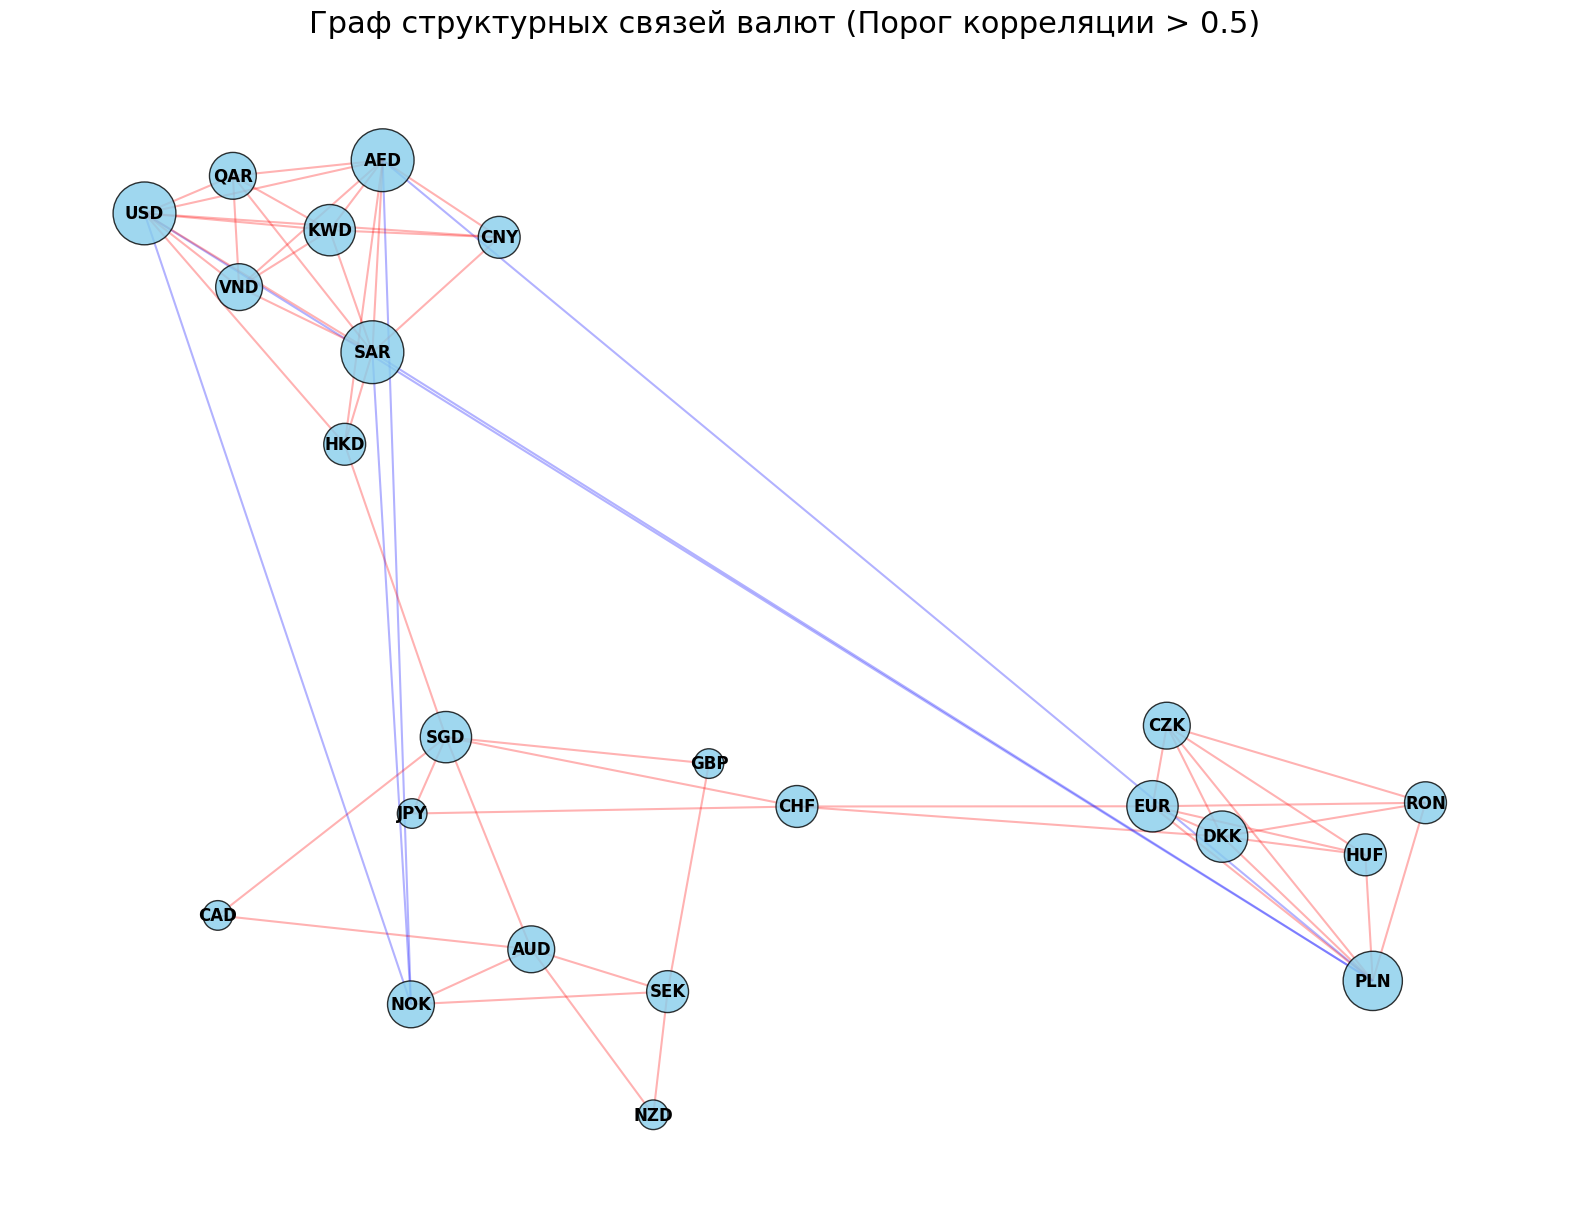

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Настройка параметров графа
# Устанавливаем порог корреляции для отображения связи (ребра)
threshold = 0.5 

# Создаем копию матрицы корреляций
adj_matrix = corr_matrix.copy()

# Обнуляем связи ниже порога и диагональ (самокорреляцию)
adj_matrix[(adj_matrix.abs() < threshold)] = 0
np.fill_diagonal(adj_matrix.values, 0)

# 2. Создание графа из матрицы смежности
G = nx.from_pandas_adjacency(adj_matrix)

# Удаляем изолированные узлы (валюты без сильных связей на этом пороге)
isolated_nodes = [node for node, degree in dict(G.degree()).items() if degree == 0]
G.remove_nodes_from(isolated_nodes)

# 3. Расчет топологических метрик
# Степень центральности (количество связей) — определяет "Ядро"
centrality = nx.degree_centrality(G)
node_sizes = [v * 5000 for v in centrality.values()]

# 4. Визуализация
plt.figure(figsize=(20, 15))

# Используем алгоритм Force-directed (Fruchterman-Reingold) для распределения узлов
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Рисуем ребра (линии)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
edge_colors = ['red' if w > 0 else 'blue' for w in weights] # Красные - прямая связь, синие - обратная

nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color=edge_colors, width=1.5)

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                       node_color='skyblue', alpha=0.8, edgecolors='black')

# Рисуем подписи (тикеры)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title(f'Граф структурных связей валют (Порог корреляции > {threshold})', fontsize=22, pad=20)
plt.axis('off')

# Добавляем информацию о периферии
print(f"🌐 Ядро рынка (макс. связей): {max(centrality, key=centrality.get)}")
print(f"🏝️ Периферия (изолированные активы на пороге {threshold}): {', '.join(isolated_nodes)}")

plt.show()